In [1]:
import pandas as pd 
import numpy as np 

data = pd.read_csv(
    "/kaggle/input/datasets/pranaymaheshwaram/hmda-home-loan-dataset-2025-loan-approval/actions_taken_1-3_year_2025.csv",
    low_memory=False
)

In [2]:
data.shape

(8942981, 99)

In [3]:
features = data.columns.tolist()
features

['activity_year',
 'lei',
 'derived_msa-md',
 'state_code',
 'county_code',
 'census_tract',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'action_taken',
 'purchaser_type',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open-end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'total_loan_costs',
 'total_points_and_fees',
 'origination_charges',
 'discount_points',
 'lender_credits',
 'loan_term',
 'prepayment_penalty_term',
 'intro_rate_period',
 'negative_amortization',
 'interest_only_payment',
 'balloon_payment',
 'other_nonamortizing_features',
 'property_value',
 'construction_method',
 'occupancy_type',
 'manufactured_home_secured_property_type',
 'manufactured_home_land_property_interest',
 'total_units',
 'multifamily_affordable_units',
 'income',
 '

In [4]:
selected_features = [
    "state_code",
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age",
    "action_taken",
    "derived_dwelling_category",
    "loan_purpose",
    "conforming_loan_limit",
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "occupancy_type",
    "income",
    "debt_to_income_ratio"
]

df = data[selected_features].copy()

In [5]:
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

(8942981, 16)

Columns:
['state_code', 'derived_ethnicity', 'derived_race', 'derived_sex', 'applicant_age', 'action_taken', 'derived_dwelling_category', 'loan_purpose', 'conforming_loan_limit', 'loan_amount', 'loan_to_value_ratio', 'loan_term', 'property_value', 'occupancy_type', 'income', 'debt_to_income_ratio']

Data types:
state_code                    object
derived_ethnicity             object
derived_race                  object
derived_sex                   object
applicant_age                 object
action_taken                   int64
derived_dwelling_category     object
loan_purpose                   int64
conforming_loan_limit         object
loan_amount                  float64
loan_to_value_ratio           object
loan_term                     object
property_value                object
occupancy_type                 int64
income                       float64
debt_to_income_ratio          object
dtype: object

Missing values:
debt_to_income_ratio         810400
income       

In [6]:
for col in df.columns:
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print(df[col].value_counts(dropna=False).head(30))


state_code
state_code
CA    749631
TX    713200
FL    687344
NC    368996
OH    360034
PA    354637
GA    329254
NY    309223
MI    300491
IL    300395
VA    257439
NJ    234838
AZ    234045
TN    228263
IN    225810
WA    220406
CO    197148
SC    189347
WI    186476
MO    182071
MA    170719
MD    169409
AL    156370
MN    147942
KY    133281
UT    120167
OR    111953
OK    104296
LA     98830
CT     96253
Name: count, dtype: int64

derived_ethnicity
derived_ethnicity
Not Hispanic or Latino     6227187
Ethnicity Not Available    1446906
Hispanic or Latino         1037925
Joint                       228064
Free Form Text Only           2899
Name: count, dtype: int64

derived_race
derived_race
White                                        5820654
Race Not Available                           1557899
Black or African American                     735892
Asian                                         523069
Joint                                         196528
American Indian or Alaska Nativ

In [7]:
for col in [
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "income"
]:
    print("\n", col)
    print(df[col].describe())


 loan_amount
count    8.942981e+06
mean     4.369559e+05
std      3.340840e+08
min      5.000000e+03
25%      1.050000e+05
50%      2.250000e+05
75%      3.750000e+05
max      9.990000e+11
Name: loan_amount, dtype: float64

 loan_to_value_ratio
count     8254309
unique     198433
top            80
freq       498728
Name: loan_to_value_ratio, dtype: object

 loan_term
count     8830881
unique        480
top           360
freq      5947940
Name: loan_term, dtype: object

 property_value
count     8596735
unique       4192
top        Exempt
freq       267340
Name: property_value, dtype: object

 income
count    8.247892e+06
mean     2.071952e+02
std      5.038883e+04
min     -1.811129e+06
25%      6.900000e+01
50%      1.080000e+02
75%      1.720000e+02
max      1.200000e+08
Name: income, dtype: float64


In [8]:
print(df["debt_to_income_ratio"].value_counts(dropna=False))

debt_to_income_ratio
30%-<36%    1112223
20%-<30%    1107410
NaN          810400
50%-60%      804960
>60%         593948
<20%         477968
49           388667
44           331573
42           303950
43           281561
41           271059
Exempt       266195
40           263950
48           263158
39           252930
45           248719
47           243354
38           239114
46           237515
37           227482
36           216845
Name: count, dtype: int64


In [9]:
print(df["action_taken"].value_counts(dropna=False))

action_taken
1    6827891
3    2115090
Name: count, dtype: int64


In [10]:
df['debt_to_income_ratio'].value_counts()

debt_to_income_ratio
30%-<36%    1112223
20%-<30%    1107410
50%-60%      804960
>60%         593948
<20%         477968
49           388667
44           331573
42           303950
43           281561
41           271059
Exempt       266195
40           263950
48           263158
39           252930
45           248719
47           243354
38           239114
46           237515
37           227482
36           216845
Name: count, dtype: int64

In [11]:
import numpy as np
import pandas as pd

for col in [
    "loan_to_value_ratio",
    "loan_term",
    "property_value"
]:
    df[col] = pd.to_numeric(
        df[col].replace("Exempt", np.nan),
        errors="coerce"
    )

In [12]:
def convert_dti(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    mapping = {
        "<20%": 10.0,
        "20%-<30%": 25.0,
        "30%-<36%": 33.0,
        "50%-60%": 55.0,
        ">60%": 65.0,
        "Exempt": np.nan
    }

    if x in mapping:
        return mapping[x]

    try:
        return float(x)
    except:
        return np.nan

df["debt_to_income_ratio"] = df["debt_to_income_ratio"].apply(convert_dti)

In [13]:
df['debt_to_income_ratio'].value_counts()

debt_to_income_ratio
33.0    1112223
25.0    1107410
55.0     804960
65.0     593948
10.0     477968
49.0     388667
44.0     331573
42.0     303950
43.0     281561
41.0     271059
40.0     263950
48.0     263158
39.0     252930
45.0     248719
47.0     243354
38.0     239114
46.0     237515
37.0     227482
36.0     216845
Name: count, dtype: int64

In [14]:
numeric_cols = [
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "income",
    "debt_to_income_ratio"
]

for col in numeric_cols:
    print("\n" + "="*50)
    print(col)
    print(df[col].describe())
    print("Missing:", df[col].isna().sum())


loan_amount
count    8.942981e+06
mean     4.369559e+05
std      3.340840e+08
min      5.000000e+03
25%      1.050000e+05
50%      2.250000e+05
75%      3.750000e+05
max      9.990000e+11
Name: loan_amount, dtype: float64
Missing: 0

loan_to_value_ratio
count    7.987767e+06
mean     7.832804e+02
std      7.627355e+05
min      1.000000e-03
25%      5.985700e+01
50%      7.769200e+01
75%      9.000600e+01
max      1.401112e+09
Name: loan_to_value_ratio, dtype: float64
Missing: 955214

loan_term
count    8.565025e+06
mean     3.187755e+02
std      8.378738e+01
min      1.000000e+00
25%      3.000000e+02
50%      3.600000e+02
75%      3.600000e+02
max      3.660000e+03
Name: loan_term, dtype: float64
Missing: 377956

property_value
count    8.329395e+06
mean     5.919773e+05
std      4.096301e+06
min      5.000000e+03
25%      2.650000e+05
50%      3.950000e+05
75%      6.250000e+05
max      2.147484e+09
Name: property_value, dtype: float64
Missing: 613586

income
count    8.247892e+06
m

In [15]:
df['loan_to_value_ratio'].value_counts()

loan_to_value_ratio
80.0000     754086
96.5000     413901
95.0000     336784
100.0000    331627
75.0000     255837
             ...  
97.3106          1
71.2405          1
67.2326          1
78.7729          1
47.0383          1
Name: count, Length: 142819, dtype: int64

In [16]:
print("Negative income:", (df["income"] < 0).sum())
print("LTV > 100:", (df["loan_to_value_ratio"] > 100).sum())
print("LTV < 0:", (df["loan_to_value_ratio"] < 0).sum())
print("Loan term <= 0:", (df["loan_term"] <= 0).sum())
print("Property value <= 0:", (df["property_value"] <= 0).sum())
print("Loan amount <= 0:", (df["loan_amount"] <= 0).sum())

Negative income: 7488
LTV > 100: 294321
LTV < 0: 0
Loan term <= 0: 0
Property value <= 0: 0
Loan amount <= 0: 0


In [17]:
print(df["applicant_age"].value_counts(dropna=False))

applicant_age
35-44    2083122
45-54    1820143
25-34    1675193
55-64    1478850
65-74     910101
>74       397511
<25       307064
8888      270997
Name: count, dtype: int64


In [18]:
df["applicant_age"] = df["applicant_age"].replace(
    [8888, "8888"],
    "Age Not Available"
)

In [19]:
print(df["applicant_age"].value_counts(dropna=False))

applicant_age
35-44                2083122
45-54                1820143
25-34                1675193
55-64                1478850
65-74                 910101
>74                   397511
<25                   307064
Age Not Available     270997
Name: count, dtype: int64


In [20]:
categorical_cols = [
    "state_code",
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age",
    "derived_dwelling_category",
    "loan_purpose",
    "conforming_loan_limit",
    "occupancy_type"
]

for col in categorical_cols:
    print(
        col,
        "missing =", df[col].isna().sum(),
        "unique =", df[col].nunique(dropna=False)
    )

state_code missing = 36080 unique = 55
derived_ethnicity missing = 0 unique = 5
derived_race missing = 0 unique = 9
derived_sex missing = 0 unique = 4
applicant_age missing = 0 unique = 8
derived_dwelling_category missing = 0 unique = 4
loan_purpose missing = 0 unique = 6
conforming_loan_limit missing = 47387 unique = 4
occupancy_type missing = 0 unique = 3


In [21]:
print("LTV > 100:", (df["loan_to_value_ratio"] > 100).sum())
print("LTV > 200:", (df["loan_to_value_ratio"] > 200).sum())
print("LTV > 500:", (df["loan_to_value_ratio"] > 500).sum())

print("Loan > $5M:", (df["loan_amount"] > 5_000_000).sum())
print("Property > $5M:", (df["property_value"] > 5_000_000).sum())
print("Term > 600 months:", (df["loan_term"] > 600).sum())

LTV > 100: 294321
LTV > 200: 3806
LTV > 500: 1706
Loan > $5M: 13360
Property > $5M: 28955
Term > 600 months: 10


In [22]:
print(
    df[
        ["loan_amount", "property_value", "loan_to_value_ratio"]
    ].sort_values(
        "loan_to_value_ratio",
        ascending=False
    ).head(20)
)

         loan_amount  property_value  loan_to_value_ratio
5333025   28025000.0             NaN         1.401112e+09
6434193     145000.0             NaN         1.400000e+09
6433010      65000.0             NaN         6.500000e+08
8306549      55000.0             NaN         5.000000e+08
5334118     755000.0       1105000.0         7.500000e+07
5334128     545000.0        725000.0         5.452500e+07
5332783     515000.0        805000.0         5.160000e+07
8579751     255000.0          5000.0         4.900000e+07
5337094     485000.0        745000.0         4.862000e+07
5334115     455000.0        605000.0         4.500000e+07
5331387     415000.0        595000.0         4.130000e+07
5334076     405000.0        585000.0         4.060000e+07
5979721      55000.0          5000.0         4.032060e+07
5337124     395000.0        505000.0         3.989500e+07
5334338     375000.0        505000.0         3.750000e+07
5334280     355000.0        475000.0         3.525000e+07
1744894     35

In [23]:
print(
    df.isna().sum().sort_values(ascending=False)
)

print("\nTotal missing values:",
      df.isna().sum().sum())

debt_to_income_ratio         1076595
loan_to_value_ratio           955214
income                        695089
property_value                613586
loan_term                     377956
conforming_loan_limit          47387
state_code                     36080
derived_ethnicity                  0
loan_purpose                       0
derived_dwelling_category          0
action_taken                       0
applicant_age                      0
derived_sex                        0
derived_race                       0
loan_amount                        0
occupancy_type                     0
dtype: int64

Total missing values: 3801907


In [24]:
df.loc[df["income"] < 0, "income"] = np.nan
df.loc[df["loan_term"] > 600, "loan_term"] = np.nan

In [25]:
print(df.isna().sum().sort_values(ascending=False))

debt_to_income_ratio         1076595
loan_to_value_ratio           955214
income                        702577
property_value                613586
loan_term                     377966
conforming_loan_limit          47387
state_code                     36080
derived_ethnicity                  0
loan_purpose                       0
derived_dwelling_category          0
action_taken                       0
applicant_age                      0
derived_sex                        0
derived_race                       0
loan_amount                        0
occupancy_type                     0
dtype: int64


In [26]:
numeric_features = [
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "income",
    "debt_to_income_ratio"
]

categorical_features = [
    "state_code",
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age",
    "derived_dwelling_category",
    "loan_purpose",
    "conforming_loan_limit",
    "occupancy_type"
]

print("NUMERICAL MISSING VALUES")
print(df[numeric_features].isna().sum())

print("\nCATEGORICAL MISSING VALUES")
print(df[categorical_features].isna().sum())


NUMERICAL MISSING VALUES
loan_amount                   0
loan_to_value_ratio      955214
loan_term                377966
property_value           613586
income                   702577
debt_to_income_ratio    1076595
dtype: int64

CATEGORICAL MISSING VALUES
state_code                   36080
derived_ethnicity                0
derived_race                     0
derived_sex                      0
applicant_age                    0
derived_dwelling_category        0
loan_purpose                     0
conforming_loan_limit        47387
occupancy_type                   0
dtype: int64


In [27]:
missing_pct = (
    df.isna().mean() * 100
).sort_values(ascending=False)

print(missing_pct)

debt_to_income_ratio         12.038436
loan_to_value_ratio          10.681159
income                        7.856184
property_value                6.861090
loan_term                     4.226398
conforming_loan_limit         0.529879
state_code                    0.403445
derived_ethnicity             0.000000
loan_purpose                  0.000000
derived_dwelling_category     0.000000
action_taken                  0.000000
applicant_age                 0.000000
derived_sex                   0.000000
derived_race                  0.000000
loan_amount                   0.000000
occupancy_type                0.000000
dtype: float64


In [28]:
df1=df.copy()

In [29]:
for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

In [30]:
df["state_code"] = df["state_code"].fillna("Unknown")
df["conforming_loan_limit"] = df["conforming_loan_limit"].fillna("Unknown")

In [31]:
print(df.isna().sum())
print("\nTotal missing values:", df.isna().sum().sum())

state_code                   0
derived_ethnicity            0
derived_race                 0
derived_sex                  0
applicant_age                0
action_taken                 0
derived_dwelling_category    0
loan_purpose                 0
conforming_loan_limit        0
loan_amount                  0
loan_to_value_ratio          0
loan_term                    0
property_value               0
occupancy_type               0
income                       0
debt_to_income_ratio         0
dtype: int64

Total missing values: 0


In [32]:
df["target"] = df["action_taken"].map({
    1: 1,
    3: 0
})

df.drop(columns=["action_taken"], inplace=True)

print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

target
1    6827891
0    2115090
Name: count, dtype: int64
target
1    0.763492
0    0.236508
Name: proportion, dtype: float64


In [33]:
# ==========================================
# SAVE DATASET AFTER TARGET CREATION
# ==========================================

output_path = "preprocessed_hmda.csv"

df.to_csv(
    output_path,
    index=False
)

print("Dataset saved successfully!")
print(f"File: {output_path}")
print(f"Shape: {df.shape}")

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget distribution (%):")
print(df["target"].value_counts(normalize=True))

Dataset saved successfully!
File: preprocessed_hmda.csv
Shape: (8942981, 16)

Target distribution:
target
1    6827891
0    2115090
Name: count, dtype: int64

Target distribution (%):
target
1    0.763492
0    0.236508
Name: proportion, dtype: float64


In [34]:
# Protected characteristics
protected_attributes = [
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age"
]

# Geographic attribute monitored for fairness
fairness_geographic_attributes = [
    "state_code"
]

# All attributes used for fairness evaluation
fairness_attributes = (
    protected_attributes
    + fairness_geographic_attributes
)

protected_data = df[fairness_attributes].copy()

print(protected_data.head())

         derived_ethnicity derived_race derived_sex applicant_age state_code
0  Ethnicity Not Available        White      Female         65-74         FL
1   Not Hispanic or Latino        White       Joint         35-44         NY
2   Not Hispanic or Latino        Asian        Male         55-64         GA
3   Not Hispanic or Latino        Asian        Male         35-44         TX
4   Not Hispanic or Latino        White        Male         25-34         AZ


In [35]:
for col in protected_attributes:
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print(protected_data[col].value_counts(dropna=False))


derived_ethnicity
derived_ethnicity
Not Hispanic or Latino     6227187
Ethnicity Not Available    1446906
Hispanic or Latino         1037925
Joint                       228064
Free Form Text Only           2899
Name: count, dtype: int64

derived_race
derived_race
White                                        5820654
Race Not Available                           1557899
Black or African American                     735892
Asian                                         523069
Joint                                         196528
American Indian or Alaska Native               64179
2 or more minority races                       22573
Native Hawaiian or Other Pacific Islander      20233
Free Form Text Only                             1954
Name: count, dtype: int64

derived_sex
derived_sex
Joint                3120584
Male                 3037996
Female               1970832
Sex Not Available     813569
Name: count, dtype: int64

applicant_age
applicant_age
35-44                2083122
45-54  

In [36]:
model_features = [
    "derived_dwelling_category",
    "loan_purpose",
    "conforming_loan_limit",
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "occupancy_type",
    "income",
    "debt_to_income_ratio"
]

X = df[model_features].copy()
y = df["target"].copy()

print(X.shape)
print(y.shape)

(8942981, 10)
(8942981,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

Train: (7154384, 10)
Test : (1788597, 10)

Train target:
target
1    0.763492
0    0.236508
Name: proportion, dtype: float64

Test target:
target
1    0.763492
0    0.236508
Name: proportion, dtype: float64


In [38]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [39]:
baseline_categorical_features = [
    "derived_dwelling_category",
    "loan_purpose",
    "conforming_loan_limit",
    "occupancy_type"
]
for col in baseline_categorical_features:
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print(X[col].value_counts(dropna=False))


derived_dwelling_category
derived_dwelling_category
Single Family (1-4 Units):Site-Built      8430982
Single Family (1-4 Units):Manufactured     464612
Multifamily:Site-Built                      45559
Multifamily:Manufactured                     1828
Name: count, dtype: int64

loan_purpose
loan_purpose
1     4199851
32    1389891
31    1330078
4     1050634
2      968209
5        4318
Name: count, dtype: int64

conforming_loan_limit
conforming_loan_limit
C          8629963
NC          264412
Unknown      47387
U             1219
Name: count, dtype: int64

occupancy_type
occupancy_type
1    7987507
3     782585
2     172889
Name: count, dtype: int64


In [40]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

baseline_categorical_features = [
    "derived_dwelling_category",
    "loan_purpose",
    "conforming_loan_limit",
    "occupancy_type"
]

baseline_numerical_features = [
    "loan_amount",
    "loan_to_value_ratio",
    "loan_term",
    "property_value",
    "income",
    "debt_to_income_ratio"
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            baseline_categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            baseline_numerical_features
        )
    ]
)

In [41]:
X.shape

(8942981, 10)

In [42]:
from sklearn.pipeline import Pipeline

In [43]:
from sklearn.model_selection import cross_validate

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [45]:
import xgboost
print(xgboost.__version__)

3.2.0


In [46]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])


xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1,
    return_train_score=False
)



for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = xgb_cv[f"test_{metric}"]
    print(f"{metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}")




xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1       :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

ACCURACY  : 0.8557 ± 0.0002
PRECISION : 0.8615 ± 0.0002
RECALL    : 0.9663 ± 0.0002
F1        : 0.9109 ± 0.0001
ROC_AUC   : 0.8536 ± 0.0003
Accuracy : 0.8556863284462626
Precision: 0.8615912548894128
Recall   : 0.9661945592309197
F1       : 0.9108997086244873
ROC-AUC  : 0.853376858406576


In [47]:
%pip install fairlearn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [48]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np

In [49]:
protected_test = df.loc[
    X_test.index,
    fairness_attributes
].copy()

print(protected_test.shape)
print(protected_test.head())

(1788597, 5)
               derived_ethnicity               derived_race  \
4054521   Not Hispanic or Latino  Black or African American   
902529        Hispanic or Latino                      White   
8836219       Hispanic or Latino                      White   
5869277   Not Hispanic or Latino                      White   
2096258  Ethnicity Not Available         Race Not Available   

               derived_sex applicant_age state_code  
4054521             Female         65-74         GA  
902529                Male         45-54         KY  
8836219               Male         45-54         CA  
5869277              Joint         55-64         OK  
2096258  Sex Not Available         45-54         MO  


In [50]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("protected_test:", protected_test.shape)

X_test: (1788597, 10)
y_test: (1788597,)
protected_test: (1788597, 5)


In [51]:
from sklearn.metrics import (
    recall_score,
    confusion_matrix
)

def true_positive_rate(y_true, y_pred):
    if np.sum(y_true == 1) == 0:
        return np.nan
    return recall_score(y_true, y_pred, zero_division=0)


def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return fp / (fp + tn) if (fp + tn) > 0 else np.nan


fairness_metrics = {
    "Selection Rate": selection_rate,
    "TPR": true_positive_rate,
    "FPR": false_positive_rate
}

In [52]:
def analyze_protected_attribute(
    attribute,
    y_true,
    y_pred,
    sensitive_features
):
    
    print("\n" + "=" * 80)
    print(f"FAIRNESS ANALYSIS: {attribute}")
    print("=" * 80)

    # Group-level metrics
    metric_frame = MetricFrame(
        metrics=fairness_metrics,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_features
    )

    print("\nGroup-wise Metrics:")
    display(metric_frame.by_group)

    # Sample size of each group
    group_counts = sensitive_features.value_counts().sort_index()

    print("\nGroup Sample Sizes:")
    display(group_counts.to_frame("Count"))

    # Fairness metrics
    dp_difference = demographic_parity_difference(
        y_true,
        y_pred,
        sensitive_features=sensitive_features
    )

    dp_ratio = demographic_parity_ratio(
        y_true,
        y_pred,
        sensitive_features=sensitive_features
    )

    eo_difference = equalized_odds_difference(
        y_true,
        y_pred,
        sensitive_features=sensitive_features
    )

    print("\nOverall Fairness Metrics:")
    print(f"Demographic Parity Difference : {dp_difference:.4f}")
    print(f"Demographic Parity Ratio      : {dp_ratio:.4f}")
    print(f"Equalized Odds Difference     : {eo_difference:.4f}")

    return {
        "attribute": attribute,
        "group_metrics": metric_frame.by_group,
        "group_counts": group_counts,
        "demographic_parity_difference": dp_difference,
        "demographic_parity_ratio": dp_ratio,
        "equalized_odds_difference": eo_difference
    }

In [53]:
race_results = analyze_protected_attribute(
    attribute="derived_race",
    y_true=y_test,
    y_pred=xgb_pred,
    sensitive_features=protected_test["derived_race"]
)


FAIRNESS ANALYSIS: derived_race

Group-wise Metrics:


,Selection Rate,TPR,FPR
derived_race,,,
2 or more minority races,0.765559,0.964968,0.425468
American Indian or Alaska Native,0.751653,0.950479,0.419269
Asian,0.877534,0.982306,0.490909
Black or African American,0.768768,0.951646,0.459381
Free Form Text Only,0.629723,0.969880,0.385281
Joint,0.884703,0.971868,0.506923
Native Hawaiian or Other Pacific Islander,0.761668,0.951859,0.431772
Race Not Available,0.854946,0.969954,0.547815
White,0.866599,0.965269,0.497572



Group Sample Sizes:


,Count
derived_race,
2 or more minority races,4483
American Indian or Alaska Native,13006
Asian,104731
Black or African American,147151
Free Form Text Only,397
Joint,39680
Native Hawaiian or Other Pacific Islander,4028
Race Not Available,311478
White,1163643



Overall Fairness Metrics:
Demographic Parity Difference : 0.2550
Demographic Parity Ratio      : 0.7118
Equalized Odds Difference     : 0.1625


In [54]:
individual_results = {}

for attribute in protected_attributes:

    individual_results[attribute] = analyze_protected_attribute(
        attribute=attribute,
        y_true=y_test,
        y_pred=xgb_pred,
        sensitive_features=protected_test[attribute]
    )


FAIRNESS ANALYSIS: derived_ethnicity

Group-wise Metrics:


,Selection Rate,TPR,FPR
derived_ethnicity,,,
Ethnicity Not Available,0.858491,0.969638,0.553140
Free Form Text Only,0.696486,0.979290,0.364583
Hispanic or Latino,0.811281,0.960867,0.459784
Joint,0.882301,0.971897,0.520930
Not Hispanic or Latino,0.862257,0.966021,0.495191



Group Sample Sizes:


,Count
derived_ethnicity,
Ethnicity Not Available,289579
Free Form Text Only,626
Hispanic or Latino,207573
Joint,45693
Not Hispanic or Latino,1245126



Overall Fairness Metrics:
Demographic Parity Difference : 0.1858
Demographic Parity Ratio      : 0.7894
Equalized Odds Difference     : 0.1886

FAIRNESS ANALYSIS: derived_race

Group-wise Metrics:


...


Overall Fairness Metrics:
Demographic Parity Difference : 0.0868
Demographic Parity Ratio      : 0.9028
Equalized Odds Difference     : 0.1741

FAIRNESS ANALYSIS: applicant_age

Group-wise Metrics:


,Selection Rate,TPR,FPR
applicant_age,,,
25-34,0.887600,0.976172,0.484888
35-44,0.870049,0.973259,0.513569
45-54,0.854030,0.967846,0.518095
55-64,0.834816,0.958082,0.498641
65-74,0.813013,0.943852,0.476092
<25,0.854869,0.966568,0.393376
>74,0.793807,0.933448,0.474528
Age Not Available,0.924709,0.989297,0.656714



Group Sample Sizes:


,Count
applicant_age,
25-34,334734
35-44,416543
45-54,363828
55-64,296101
65-74,182136
<25,61820
>74,79285
Age Not Available,54150



Overall Fairness Metrics:
Demographic Parity Difference : 0.1309
Demographic Parity Ratio      : 0.8584
Equalized Odds Difference     : 0.2633


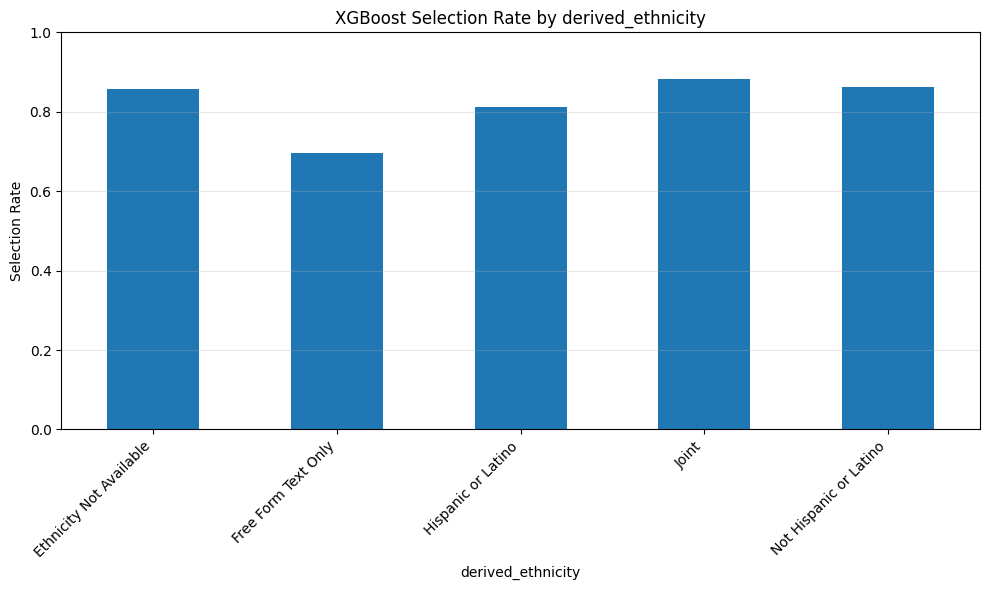

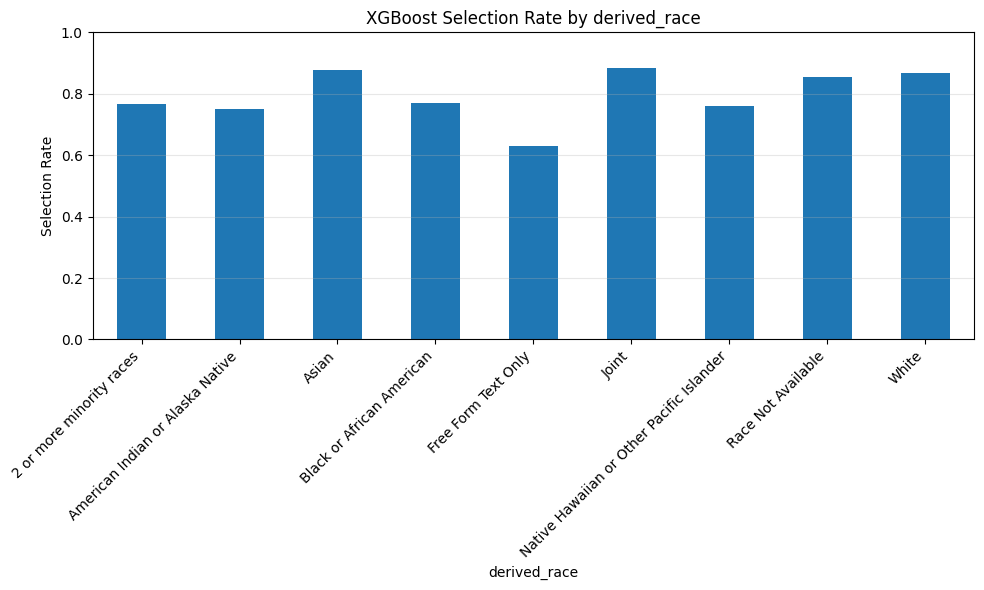

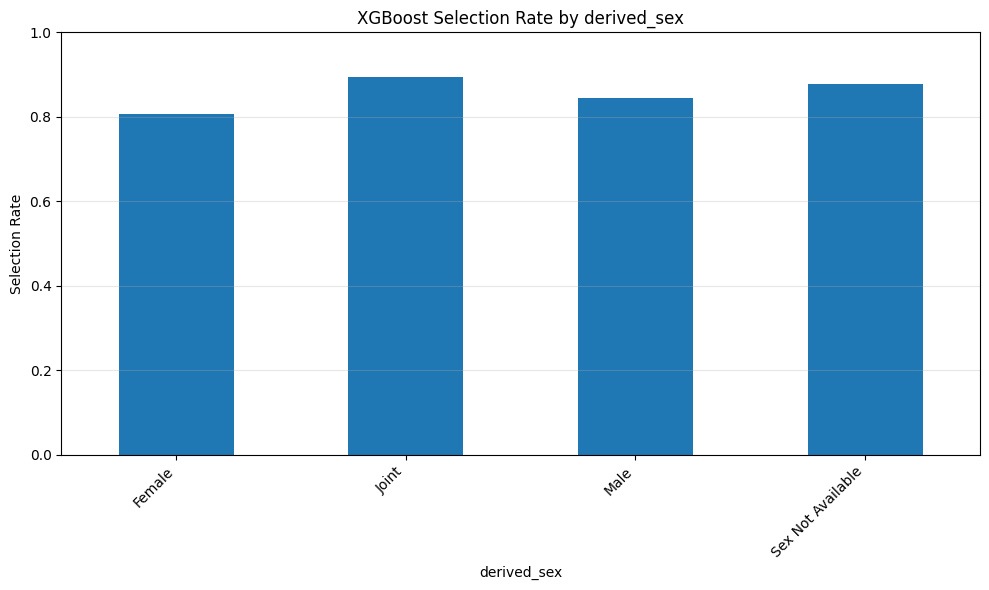

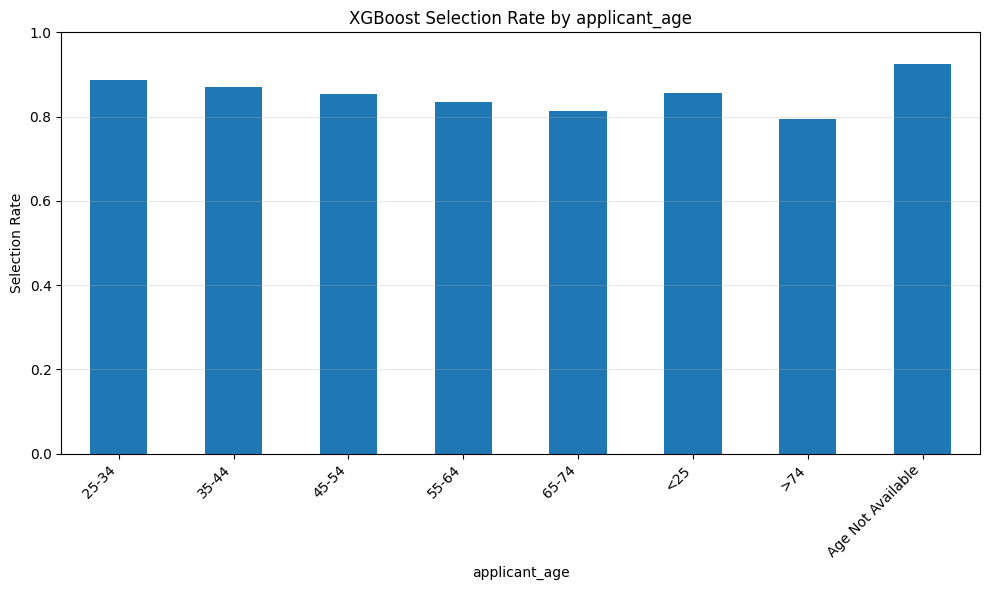

In [55]:
import matplotlib.pyplot as plt

for attribute, result in individual_results.items():

    group_metrics = result["group_metrics"]

    plt.figure(figsize=(10, 6))

    group_metrics["Selection Rate"].plot(
        kind="bar"
    )

    plt.title(f"XGBoost Selection Rate by {attribute}")
    plt.xlabel(attribute)
    plt.ylabel("Selection Rate")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

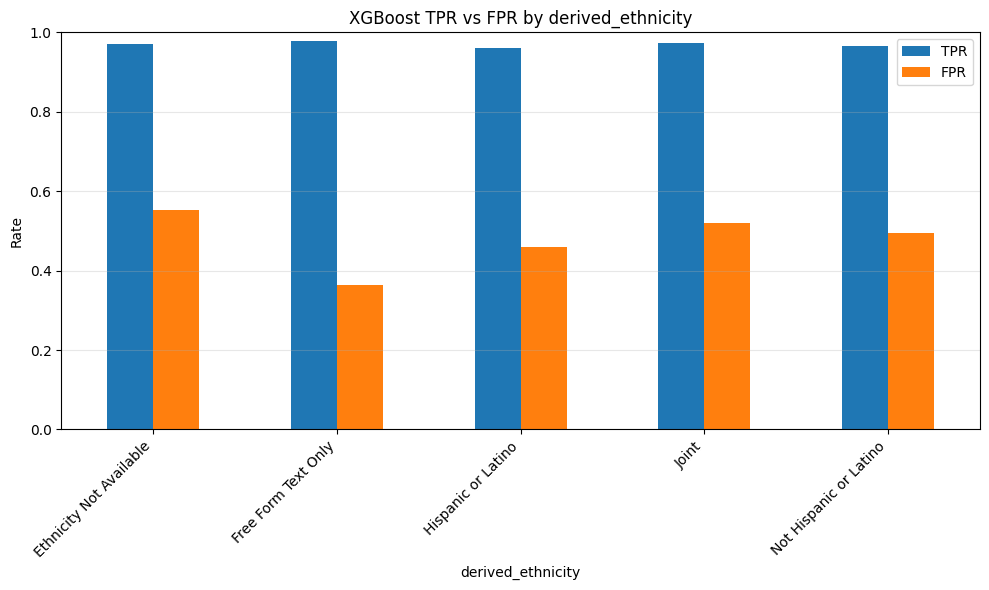

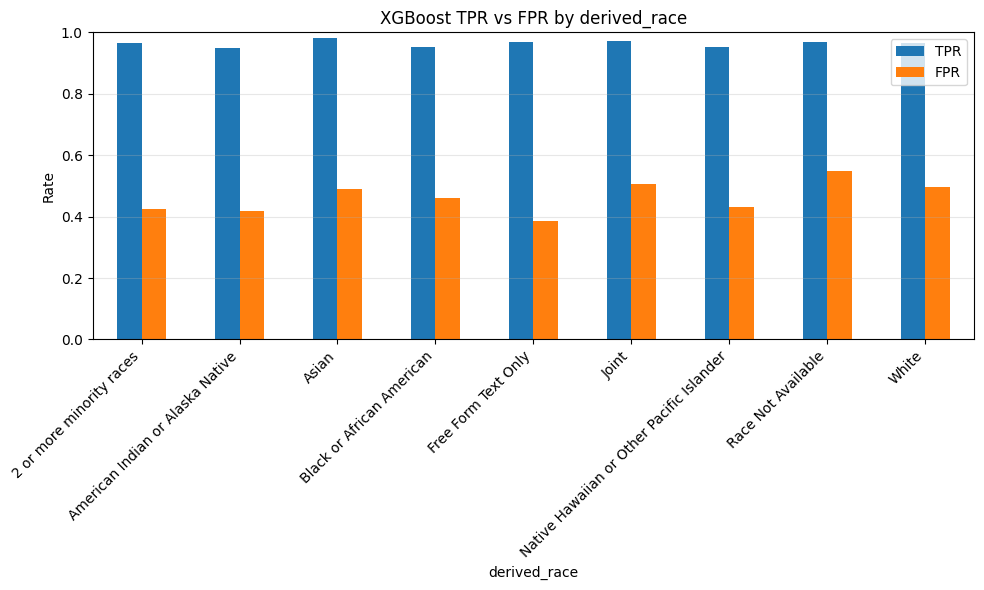

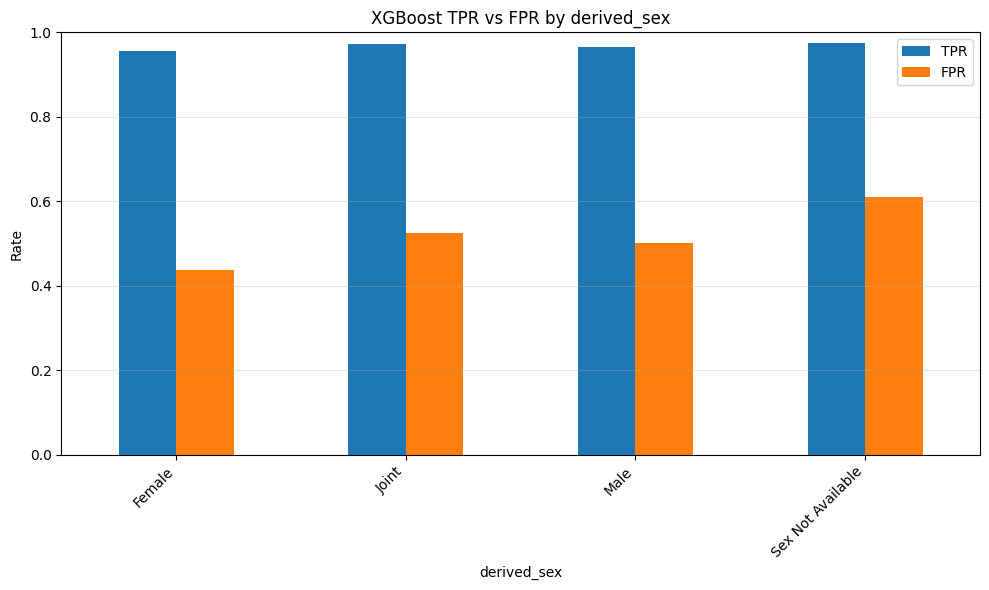

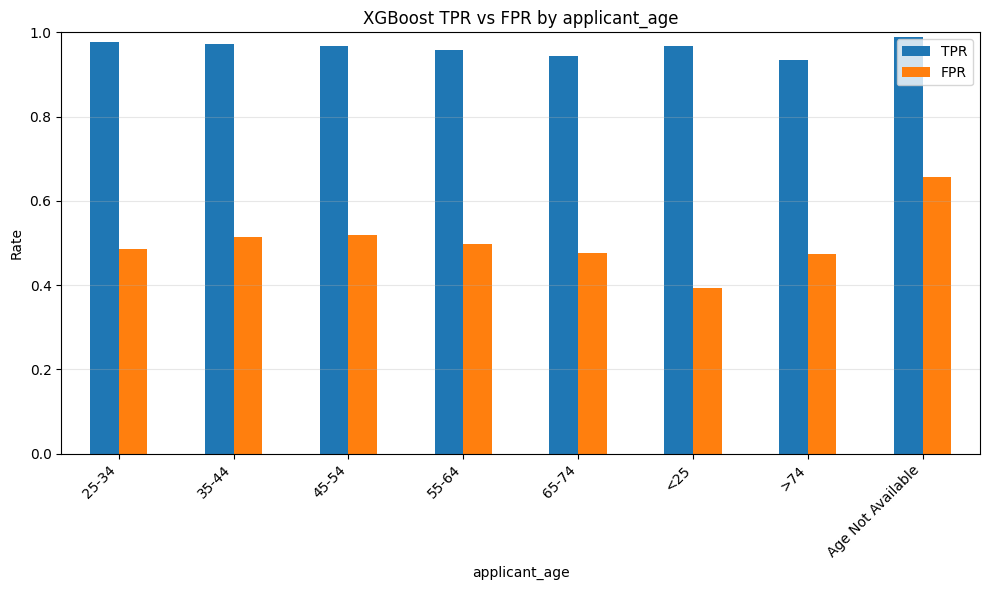

In [56]:
for attribute, result in individual_results.items():

    group_metrics = result["group_metrics"]

    ax = group_metrics[
        ["TPR", "FPR"]
    ].plot(
        kind="bar",
        figsize=(10, 6)
    )

    ax.set_title(f"XGBoost TPR vs FPR by {attribute}")
    ax.set_xlabel(attribute)
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1)

    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [57]:
fairness_summary = pd.DataFrame([
    {
        "Attribute": attribute,
        "DP Difference": result["demographic_parity_difference"],
        "DP Ratio": result["demographic_parity_ratio"],
        "EO Difference": result["equalized_odds_difference"]
    }
    for attribute, result in individual_results.items()
])

display(fairness_summary)

,Attribute,DP Difference,DP Ratio,EO Difference
0,derived_ethnicity,0.185816,0.789396,0.188557
1,derived_race,0.254980,0.711791,0.162533
2,derived_sex,0.086810,0.902820,0.174087
3,applicant_age,0.130902,0.858440,0.263338


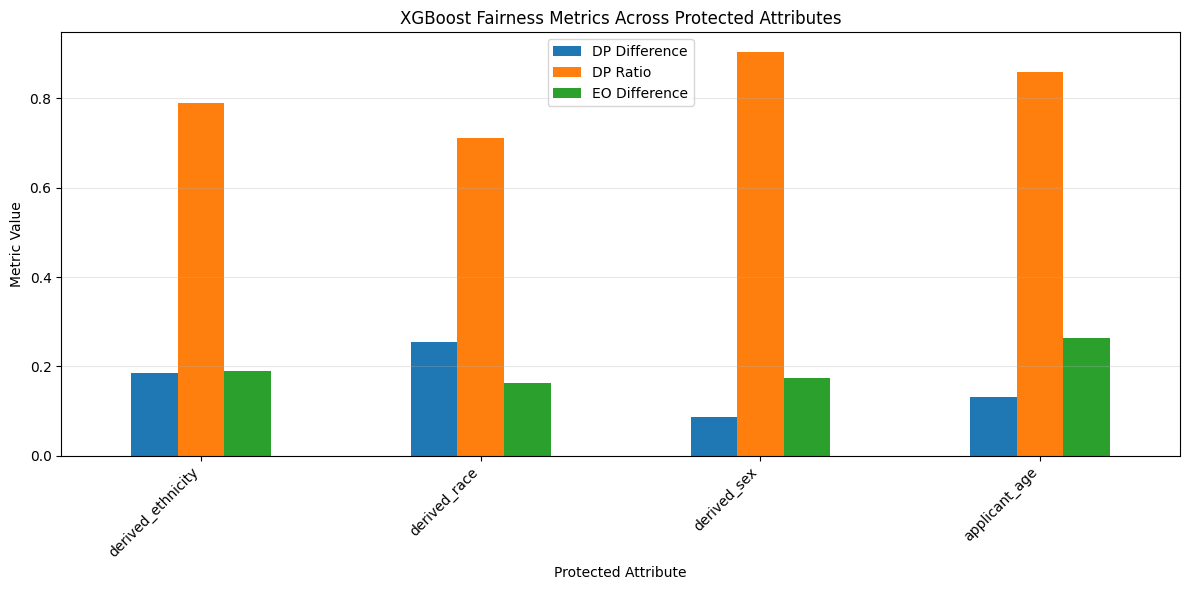

In [58]:
fairness_summary.set_index("Attribute")[
    ["DP Difference", "DP Ratio", "EO Difference"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("XGBoost Fairness Metrics Across Protected Attributes")
plt.xlabel("Protected Attribute")
plt.ylabel("Metric Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
protected_test = df.loc[
    X_test.index,
    protected_attributes
].copy()

print(protected_test.shape)
print(X_test.shape)

(1788597, 4)
(1788597, 10)


In [60]:
from itertools import combinations

protected_attributes = [
    "derived_race",
    "derived_sex",
    "derived_ethnicity",
    "applicant_age",
]

two_way_combinations = list(
    combinations(protected_attributes, 2)
)

two_way_combinations

[('derived_race', 'derived_sex'),
 ('derived_race', 'derived_ethnicity'),
 ('derived_race', 'applicant_age'),
 ('derived_sex', 'derived_ethnicity'),
 ('derived_sex', 'applicant_age'),
 ('derived_ethnicity', 'applicant_age')]

In [61]:
two_way_results = {}

for attr1, attr2 in two_way_combinations:

    combination_name = f"{attr1} × {attr2}"

    sensitive_features = (
        protected_test[attr1].astype(str)
        + " × "
        + protected_test[attr2].astype(str)
    )

    print("\n" + "=" * 90)
    print(combination_name)
    print("=" * 90)

    # Check subgroup sizes
    print("\nSubgroup sizes:")
    print(sensitive_features.value_counts())


derived_race × derived_sex

Subgroup sizes:
White × Joint                                                    468958
White × Male                                                     425815
White × Female                                                   263514
Race Not Available × Sex Not Available                           155288
Race Not Available × Male                                         66100
Black or African American × Female                                60624
Black or African American × Male                                  56448
Race Not Available × Joint                                        51377
Asian × Male                                                      45915
Race Not Available × Female                                       38713
Joint × Joint                                                     36919
Asian × Joint                                                     33828
Black or African American × Joint                                 29029
Asian × Female     

In [62]:
two_way_results = {}

for attr1, attr2 in two_way_combinations:

    combination_name = f"{attr1} × {attr2}"

    sensitive_features = (
        protected_test[attr1].astype(str)
        + " × "
        + protected_test[attr2].astype(str)
    )

    metric_frame = MetricFrame(
        metrics=fairness_metrics,
        y_true=y_test,
        y_pred=xgb_pred,
        sensitive_features=sensitive_features
    )

    dp_difference = demographic_parity_difference(
        y_test,
        xgb_pred,
        sensitive_features=sensitive_features
    )

    dp_ratio = demographic_parity_ratio(
        y_test,
        xgb_pred,
        sensitive_features=sensitive_features
    )

    eo_difference = equalized_odds_difference(
        y_test,
        xgb_pred,
        sensitive_features=sensitive_features
    )

    two_way_results[combination_name] = {
        "group_metrics": metric_frame.by_group,
        "group_counts": sensitive_features.value_counts(),
        "dp_difference": dp_difference,
        "dp_ratio": dp_ratio,
        "eo_difference": eo_difference
    }

    print("\n" + "=" * 90)
    print(f"2-WAY FAIRNESS: {combination_name}")
    print("=" * 90)

    print("\nGroup Metrics:")
    display(metric_frame.by_group)

    print("\nFairness Metrics:")
    print(f"DP Difference : {dp_difference:.4f}")
    print(f"DP Ratio      : {dp_ratio:.4f}")
    print(f"EO Difference : {eo_difference:.4f}")


2-WAY FAIRNESS: derived_race × derived_sex

Group Metrics:


,Selection Rate,TPR,FPR
sensitive_feature_0,,,
2 or more minority races × Female,0.732063,0.957609,0.415267
2 or more minority races × Joint,0.826683,0.975177,0.474790
2 or more minority races × Male,0.769907,0.965649,0.421981
2 or more minority races × Sex Not Available,0.677966,0.968750,0.333333
American Indian or Alaska Native × Female,0.714320,0.944244,0.369434
American Indian or Alaska Native × Joint,0.753661,0.946559,0.401773
American Indian or Alaska Native × Male,0.774505,0.955131,0.457846
American Indian or Alaska Native × Sex Not Available,0.710526,0.953125,0.400000
Asian × Female,0.858060,0.979296,0.469995



Fairness Metrics:
DP Difference : 0.2987
DP Ratio      : 0.6687
EO Difference : 0.3345

2-WAY FAIRNESS: derived_race × derived_ethnicity

Group Metrics:


,Selection Rate,TPR,FPR
sensitive_feature_0,,,
2 or more minority races × Ethnicity Not Available,0.658784,0.967742,0.319149
2 or more minority races × Free Form Text Only,0.500000,1.000000,0.333333
2 or more minority races × Hispanic or Latino,0.732934,0.958763,0.420000
2 or more minority races × Joint,0.782730,0.970339,0.422764
2 or more minority races × Not Hispanic or Latino,0.783920,0.965606,0.442623
American Indian or Alaska Native × Ethnicity Not Available,0.604726,0.912664,0.306554
American Indian or Alaska Native × Free Form Text Only,0.666667,1.000000,0.500000
American Indian or Alaska Native × Hispanic or Latino,0.772414,0.960951,0.444838
American Indian or Alaska Native × Joint,0.797468,0.949074,0.470000



Fairness Metrics:
DP Difference : 0.5000
DP Ratio      : 0.5000
EO Difference : 0.7805

2-WAY FAIRNESS: derived_race × applicant_age

Group Metrics:


...


Fairness Metrics:
DP Difference : 0.3171
DP Ratio      : 0.6586
EO Difference : 0.3889

2-WAY FAIRNESS: derived_sex × applicant_age

Group Metrics:


,Selection Rate,TPR,FPR
sensitive_feature_0,,,
Female × 25-34,0.840064,0.972748,0.402397
Female × 35-44,0.820342,0.964935,0.446618
Female × 45-54,0.813896,0.959403,0.466141
Female × 55-64,0.795830,0.947392,0.448486
Female × 65-74,0.772272,0.929100,0.420090
Female × <25,0.797823,0.963160,0.316276
Female × >74,0.755090,0.917120,0.423677
Female × Age Not Available,0.553757,0.973510,0.464986
Joint × 25-34,0.917377,0.978776,0.505978



Fairness Metrics:
DP Difference : 0.3918
DP Ratio      : 0.5857
EO Difference : 0.3909

2-WAY FAIRNESS: derived_ethnicity × applicant_age

Group Metrics:


,Selection Rate,TPR,FPR
sensitive_feature_0,,,
Ethnicity Not Available × 25-34,0.878345,0.976297,0.532379
Ethnicity Not Available × 35-44,0.861038,0.972987,0.544412
Ethnicity Not Available × 45-54,0.844257,0.967947,0.547172
Ethnicity Not Available × 55-64,0.821352,0.956242,0.537947
Ethnicity Not Available × 65-74,0.791264,0.942942,0.520725
Ethnicity Not Available × <25,0.817229,0.957039,0.412253
Ethnicity Not Available × >74,0.782956,0.935203,0.541676
Ethnicity Not Available × Age Not Available,0.942736,0.989520,0.697483
Free Form Text Only × 25-34,0.784314,1.000000,0.421053



Fairness Metrics:
DP Difference : 0.4773
DP Ratio      : 0.5227
EO Difference : 1.0000


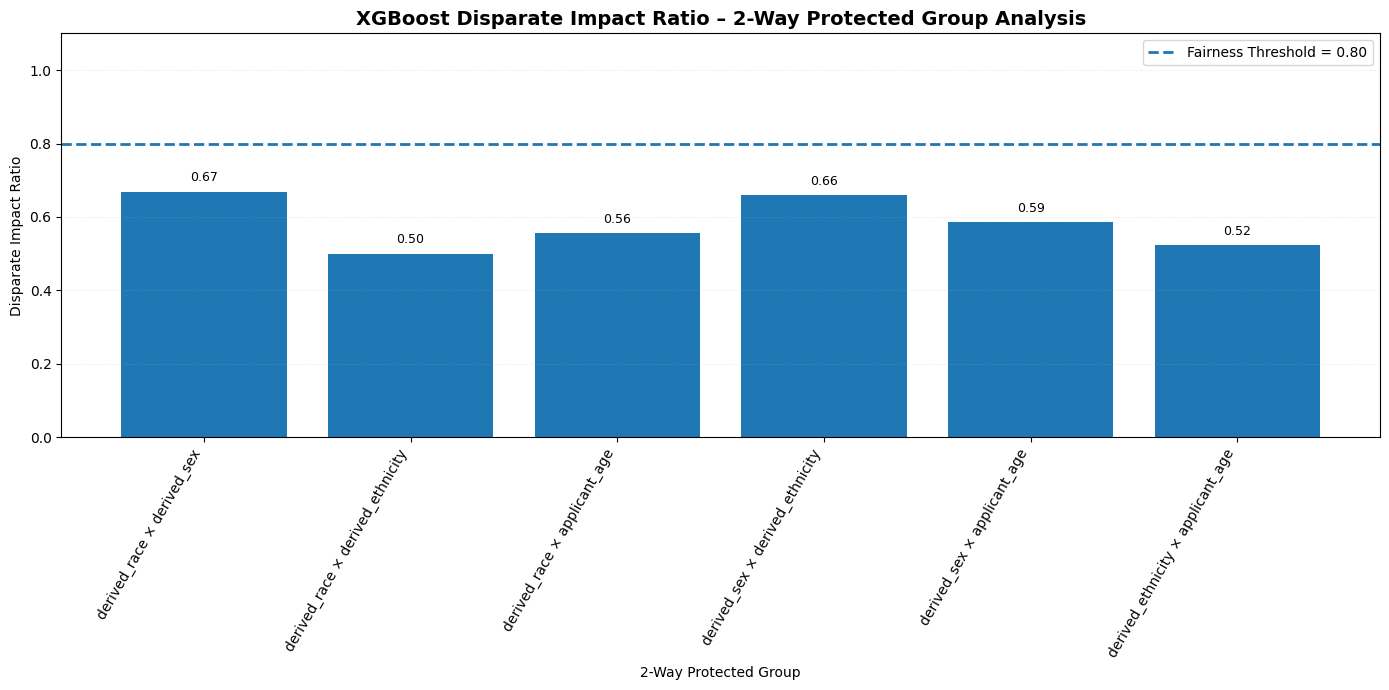

In [63]:
import matplotlib.pyplot as plt

two_way_dir = pd.DataFrame([
    {
        "2-Way Protected Group": combination,
        "Disparate Impact Ratio": result["dp_ratio"]
    }
    for combination, result in two_way_results.items()
])

plt.figure(figsize=(14, 7))

bars = plt.bar(
    two_way_dir["2-Way Protected Group"],
    two_way_dir["Disparate Impact Ratio"]
)

# 0.8 threshold
plt.axhline(
    y=0.8,
    linestyle="--",
    linewidth=2,
    label="Fairness Threshold = 0.80"
)

# Add values above bars
for bar, value in zip(
    bars,
    two_way_dir["Disparate Impact Ratio"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "XGBoost Disparate Impact Ratio – 2-Way Protected Group Analysis",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("2-Way Protected Group")
plt.ylabel("Disparate Impact Ratio")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylim(0, 1.1)

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

# BIAS MITIGATION MODEL

In [64]:
protected_train = df.loc[
    X_train.index,
    protected_attributes
].copy()

protected_test = df.loc[
    X_test.index,
    fairness_attributes
].copy()

In [65]:
print(X_train.shape)
print(y_train.shape)
print(protected_train.shape)

print(X_test.shape)
print(y_test.shape)
print(protected_test.shape)

(7154384, 10)
(7154384,)
(7154384, 4)
(1788597, 10)
(1788597,)
(1788597, 5)


In [66]:
import pandas as pd
import numpy as np

from itertools import combinations

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)

from sklearn.metrics import recall_score, confusion_matrix


class FairnessAnalyzer:

    def __init__(
        self,
        protected_attributes,
        fairness_metrics=None
    ):
        self.protected_attributes = protected_attributes

        if fairness_metrics is None:
            self.fairness_metrics = {
                "Selection Rate": selection_rate,
                "TPR": self.true_positive_rate,
                "FPR": self.false_positive_rate
            }
        else:
            self.fairness_metrics = fairness_metrics

    # -----------------------------
    # TPR
    # -----------------------------
    @staticmethod
    def true_positive_rate(y_true, y_pred):

        if np.sum(np.asarray(y_true) == 1) == 0:
            return np.nan

        return recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

    # -----------------------------
    # FPR
    # -----------------------------
    @staticmethod
    def false_positive_rate(y_true, y_pred):

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        return (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

    # -----------------------------
    # Core fairness calculation
    # -----------------------------
    def _calculate_fairness(
        self,
        y_true,
        y_pred,
        sensitive_features
    ):

        metric_frame = MetricFrame(
            metrics=self.fairness_metrics,
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=sensitive_features
        )

        group_counts = (
            pd.Series(sensitive_features)
            .value_counts()
            .sort_index()
        )

        dp_difference = demographic_parity_difference(
            y_true,
            y_pred,
            sensitive_features=sensitive_features
        )

        dp_ratio = demographic_parity_ratio(
            y_true,
            y_pred,
            sensitive_features=sensitive_features
        )

        eo_difference = equalized_odds_difference(
            y_true,
            y_pred,
            sensitive_features=sensitive_features
        )

        return {
            "group_metrics": metric_frame.by_group,
            "group_counts": group_counts,
            "dp_difference": dp_difference,
            "dp_ratio": dp_ratio,
            "eo_difference": eo_difference
        }

    # -----------------------------
    # 1-Way Analysis
    # -----------------------------
    def one_way_analysis(
        self,
        y_true,
        y_pred,
        protected_test
    ):

        results = {}

        for attribute in self.protected_attributes:

            sensitive_features = protected_test[attribute]

            results[attribute] = self._calculate_fairness(
                y_true=y_true,
                y_pred=y_pred,
                sensitive_features=sensitive_features
            )

        return results

    # -----------------------------
    # 2-Way Analysis
    # -----------------------------
    def two_way_analysis(
        self,
        y_true,
        y_pred,
        protected_test
    ):

        results = {}

        combinations_2way = combinations(
            self.protected_attributes,
            2
        )

        for attr1, attr2 in combinations_2way:

            combination_name = (
                f"{attr1} × {attr2}"
            )

            sensitive_features = (
                protected_test[attr1].astype(str)
                + " × "
                + protected_test[attr2].astype(str)
            )

            results[combination_name] = (
                self._calculate_fairness(
                    y_true=y_true,
                    y_pred=y_pred,
                    sensitive_features=sensitive_features
                )
            )

        return results

    # -----------------------------
    # Print 1-Way Results
    # -----------------------------
    def print_one_way_results(
        self,
        results
    ):

        for attribute, result in results.items():

            print("\n" + "=" * 90)
            print(f"1-WAY FAIRNESS: {attribute}")
            print("=" * 90)

            print("\nGroup Metrics:")
            display(result["group_metrics"])

            print("\nGroup Counts:")
            display(
                result["group_counts"]
                .to_frame("Count")
            )

            print("\nFairness Metrics:")
            print(
                f"DP Difference : "
                f"{result['dp_difference']:.4f}"
            )

            print(
                f"DP Ratio      : "
                f"{result['dp_ratio']:.4f}"
            )

            print(
                f"EO Difference : "
                f"{result['eo_difference']:.4f}"
            )

    # -----------------------------
    # Print 2-Way Results
    # -----------------------------
    def print_two_way_results(
        self,
        results
    ):

        for combination, result in results.items():

            print("\n" + "=" * 90)
            print(
                f"2-WAY FAIRNESS: "
                f"{combination}"
            )
            print("=" * 90)

            print("\nGroup Metrics:")
            display(result["group_metrics"])

            print("\nGroup Counts:")
            display(
                result["group_counts"]
                .to_frame("Count")
            )

            print("\nFairness Metrics:")

            print(
                f"DP Difference : "
                f"{result['dp_difference']:.4f}"
            )

            print(
                f"DP Ratio      : "
                f"{result['dp_ratio']:.4f}"
            )

            print(
                f"EO Difference : "
                f"{result['eo_difference']:.4f}"
            )

    # -----------------------------
    # Summary Table
    # -----------------------------
    @staticmethod
    def summary_table(results):

        rows = []

        for attribute, result in results.items():

            rows.append({
                "Protected Group": attribute,
                "DP Difference":
                    result["dp_difference"],
                "DP Ratio":
                    result["dp_ratio"],
                "EO Difference":
                    result["eo_difference"]
            })

        return pd.DataFrame(rows)

In [67]:
protected_attributes = [
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "applicant_age",
]

In [68]:
from sklearn.base import clone
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

In [69]:
# Race is used ONLY as the sensitive feature.
# It is NOT added to X_train/X_test.

race_train = protected_train["derived_race"].astype(str)
race_test = protected_test["derived_race"].astype(str)

print("Number of race groups:", race_train.nunique())

print("\nRace group counts:")
display(race_train.value_counts())

Number of race groups: 9

Race group counts:


derived_race
White                                        4657011
Race Not Available                           1246421
Black or African American                     588741
Asian                                         418338
Joint                                         156848
American Indian or Alaska Native               51173
2 or more minority races                       18090
Native Hawaiian or Other Pacific Islander      16205
Free Form Text Only                             1557
Name: count, dtype: int64

In [70]:
expgrad_race = ExponentiatedGradient(
    estimator=clone(xgb_model),
    constraints=DemographicParity(),
    eps=0.01,
    max_iter = 20,
    sample_weight_name="model__sample_weight"
)

In [71]:
expgrad_race.fit(
    X_train,
    y_train,
    sensitive_features=race_train
)

print("Race-based Exponentiated Gradient model trained successfully.")

Race-based Exponentiated Gradient model trained successfully.


In [72]:
expgrad_race_pred = expgrad_race.predict(X_test)

print("Predictions generated.")
print("Predicted class distribution:")
print(pd.Series(expgrad_race_pred).value_counts())

Predictions generated.
Predicted class distribution:
1    1607820
0     180777
Name: count, dtype: int64


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("\n" + "=" * 60)
print("EXPONENTIATED GRADIENT - RACE")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y_test, expgrad_race_pred):.4f}")
print(f"Precision : {precision_score(y_test, expgrad_race_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, expgrad_race_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, expgrad_race_pred, zero_division=0):.4f}")


EXPONENTIATED GRADIENT - RACE
Accuracy  : 0.8072
Precision : 0.8174
Recall    : 0.9625
F1 Score  : 0.8840


In [74]:
fairness_analyzer = FairnessAnalyzer(
    protected_attributes=[
        "derived_ethnicity",
        "derived_race",
        "derived_sex",
        "applicant_age",
    ]
)

one_way_expgrad_race = fairness_analyzer.one_way_analysis(
    y_true=y_test,
    y_pred=expgrad_race_pred,
    protected_test=protected_test
)

In [75]:
fairness_analyzer.print_one_way_results(
    one_way_expgrad_race
)


1-WAY FAIRNESS: derived_ethnicity

Group Metrics:


,Selection Rate,TPR,FPR
derived_ethnicity,,,
Ethnicity Not Available,0.889612,0.959030,0.698901
Free Form Text Only,0.829073,0.970414,0.663194
Hispanic or Latino,0.897015,0.978071,0.706549
Joint,0.911387,0.965642,0.692553
Not Hispanic or Latino,0.900992,0.960742,0.689624



Group Counts:


,Count
derived_ethnicity,
Ethnicity Not Available,289579
Free Form Text Only,626
Hispanic or Latino,207573
Joint,45693
Not Hispanic or Latino,1245126



Fairness Metrics:
DP Difference : 0.0823
DP Ratio      : 0.9097
EO Difference : 0.0434

1-WAY FAIRNESS: derived_race

Group Metrics:


...


Fairness Metrics:
DP Difference : 0.0164
DP Ratio      : 0.9819
EO Difference : 0.0290

1-WAY FAIRNESS: applicant_age

Group Metrics:


,Selection Rate,TPR,FPR
applicant_age,,,
25-34,0.938629,0.982616,0.738633
35-44,0.907107,0.966631,0.701514
45-54,0.886375,0.954901,0.684117
55-64,0.875394,0.947387,0.679049
65-74,0.872721,0.949714,0.674459
<25,0.945228,0.990075,0.759940
>74,0.865712,0.950906,0.670922
Age Not Available,0.887553,0.948114,0.636269



Group Counts:


,Count
applicant_age,
25-34,334734
35-44,416543
45-54,363828
55-64,296101
65-74,182136
<25,61820
>74,79285
Age Not Available,54150



Fairness Metrics:
DP Difference : 0.0795
DP Ratio      : 0.9159
EO Difference : 0.1237


In [76]:
two_way_expgrad_race = fairness_analyzer.two_way_analysis(
    y_true=y_test,
    y_pred=expgrad_race_pred,
    protected_test=protected_test
)

fairness_analyzer.print_two_way_results(
    two_way_expgrad_race
)


2-WAY FAIRNESS: derived_ethnicity × derived_race

Group Metrics:


,Selection Rate,TPR,FPR
sensitive_feature_0,,,
Ethnicity Not Available × 2 or more minority races,0.817568,0.961290,0.659574
Ethnicity Not Available × American Indian or Alaska Native,0.822771,0.978166,0.672304
Ethnicity Not Available × Asian,0.875915,0.967660,0.609158
Ethnicity Not Available × Black or African American,0.836932,0.973533,0.688593
Ethnicity Not Available × Free Form Text Only,0.954545,1.000000,0.928571
Ethnicity Not Available × Joint,0.869528,0.947431,0.670732
Ethnicity Not Available × Native Hawaiian or Other Pacific Islander,0.827715,0.953488,0.600000
Ethnicity Not Available × Race Not Available,0.893528,0.959025,0.704752
Ethnicity Not Available × White,0.877506,0.955514,0.678301



Group Counts:


,Count
Ethnicity Not Available × 2 or more minority races,296
Ethnicity Not Available × American Indian or Alaska Native,931
Ethnicity Not Available × Asian,4779
Ethnicity Not Available × Black or African American,7040
Ethnicity Not Available × Free Form Text Only,22
Ethnicity Not Available × Joint,1165
Ethnicity Not Available × Native Hawaiian or Other Pacific Islander,267
Ethnicity Not Available × Race Not Available,242702
Ethnicity Not Available × White,32377
Free Form Text Only × 2 or more minority races,8



Fairness Metrics:
DP Difference : 0.3333
DP Ratio      : 0.6667
EO Difference : 0.5000

2-WAY FAIRNESS: derived_ethnicity × derived_sex

Group Metrics:


...


Fairness Metrics:
DP Difference : 0.4048
DP Ratio      : 0.5952
EO Difference : 0.8200

2-WAY FAIRNESS: derived_sex × applicant_age

Group Metrics:


,Selection Rate,TPR,FPR
sensitive_feature_0,,,
Female × 25-34,0.930527,0.989038,0.737526
Female × 35-44,0.904707,0.979451,0.711520
Female × 45-54,0.891080,0.970693,0.700808
Female × 55-64,0.883475,0.965039,0.696551
Female × 65-74,0.875359,0.961357,0.682235
Female × <25,0.927939,0.992179,0.740839
Female × >74,0.858150,0.953622,0.662874
Female × Age Not Available,0.643931,0.933775,0.582633
Joint × 25-34,0.944395,0.977324,0.723761



Group Counts:


,Count
Female × 25-34,63838
Female × 35-44,86659
Female × 45-54,86054
Female × 55-64,73581
Female × 65-74,48435
Female × <25,11851
Female × >74,23821
Female × Age Not Available,865
Joint × 25-34,128172
Joint × 35-44,149174



Fairness Metrics:
DP Difference : 0.3534
DP Ratio      : 0.6291
EO Difference : 0.2423


In [77]:
expgrad_race_one_way_summary = (
    fairness_analyzer.summary_table(
        one_way_expgrad_race
    )
)

display(expgrad_race_one_way_summary)

expgrad_race_two_way_summary = (
    fairness_analyzer.summary_table(
        two_way_expgrad_race
    )
)

display(expgrad_race_two_way_summary)

,Protected Group,DP Difference,DP Ratio,EO Difference
0,derived_ethnicity,0.082313,0.909683,0.043354
1,derived_race,0.052298,0.942608,0.152426
2,derived_sex,0.016354,0.981926,0.029039
3,applicant_age,0.079516,0.915877,0.123672


,Protected Group,DP Difference,DP Ratio,EO Difference
0,derived_ethnicity × derived_race,0.333333,0.666667,0.500000
1,derived_ethnicity × derived_sex,0.187050,0.812950,0.361111
2,derived_ethnicity × applicant_age,0.454545,0.545455,1.000000
3,derived_race × derived_sex,0.103107,0.887519,0.300000
4,derived_race × applicant_age,0.404837,0.595163,0.820000
5,derived_sex × applicant_age,0.353414,0.629105,0.242339


In [78]:
# -----------------------------------------
# Geographic Fairness: State
# -----------------------------------------

state_expgrad_result = analyze_protected_attribute(
    attribute="state_code",
    y_true=y_test,
    y_pred=expgrad_race_pred,
    sensitive_features=protected_test["state_code"]
)

print("\n" + "=" * 90)
print("STATE FAIRNESS AFTER RACE MITIGATION")
print("=" * 90)

print("\nGroup Metrics:")
display(state_expgrad_result["group_metrics"])

print("\nGroup Counts:")
display(
    state_expgrad_result["group_counts"].to_frame("Count")
)

print("\nFairness Metrics:")
print(
    f"DP Difference : "
    f"{state_expgrad_result['demographic_parity_difference']:.4f}"
)

print(
    f"DP Ratio      : "
    f"{state_expgrad_result['demographic_parity_ratio']:.4f}"
)

print(
    f"EO Difference : "
    f"{state_expgrad_result['equalized_odds_difference']:.4f}"
)


FAIRNESS ANALYSIS: state_code

Group-wise Metrics:


,Selection Rate,TPR,FPR
state_code,,,
AK,0.934352,0.979505,0.737430
AL,0.902348,0.963919,0.728797
AR,0.903294,0.965672,0.705421
AZ,0.911039,0.966605,0.704141
CA,0.883743,0.952574,0.660190
CO,0.895871,0.957178,0.661031
CT,0.897636,0.953405,0.699195
DC,0.881000,0.954497,0.645161
DE,0.908372,0.960258,0.737257



Group Sample Sizes:


,Count
state_code,
AK,2879
AL,31428
AR,17548
AZ,46762
CA,149969
CO,39432
CT,19245
DC,2479
DE,7083



Overall Fairness Metrics:
Demographic Parity Difference : 0.3684
Demographic Parity Ratio      : 0.6228
Equalized Odds Difference     : 0.4036

STATE FAIRNESS AFTER RACE MITIGATION

Group Metrics:


,Selection Rate,TPR,FPR
state_code,,,
AK,0.934352,0.979505,0.737430
AL,0.902348,0.963919,0.728797
AR,0.903294,0.965672,0.705421
AZ,0.911039,0.966605,0.704141
CA,0.883743,0.952574,0.660190
CO,0.895871,0.957178,0.661031
CT,0.897636,0.953405,0.699195
DC,0.881000,0.954497,0.645161
DE,0.908372,0.960258,0.737257



Group Counts:


,Count
state_code,
AK,2879
AL,31428
AR,17548
AZ,46762
CA,149969
CO,39432
CT,19245
DC,2479
DE,7083



Fairness Metrics:
DP Difference : 0.3684
DP Ratio      : 0.6228
EO Difference : 0.4036
